In [ ]:
from pathlib import Path
import numpy as np
from PIL import Image

FOLDER = Path("bildeoppgave2/carsblob/hatchback/")  

patterns = ["*.bmp","*.png","*.jpg","*.jpeg","*.webp","*.tif","*.tiff"]
files = [p for pat in patterns for p in FOLDER.glob(pat)]
assert files, f"No image files found in {FOLDER.resolve()}"

def load_gray_01(path, target_size=None):
    """Load image, convert to grayscale, optional resize, return float32 array in [0,1]."""
    img = Image.open(path).convert("L")
    if target_size is not None:
        # Note: target_size is (H, W)
        img = img.resize((target_size[1], target_size[0]), Image.BILINEAR)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr

images = []
shapes = []
for f in files:
    arr = load_gray_01(f)
    images.append(arr)
    shapes.append(arr.shape)  # (H, W)






Fant 8 bilder i bildeoppgave2\fjes\2
------------------------------------------------------------

[Bilde 1/8] Prosesserer: Anger.jpg
blobs detektert: 10
    - Blob på (1258, 1814), radius: 82px
    - Blob på (672, 1795), radius: 108px
    - Blob på (850, 2201), radius: 101px
    - Blob på (1420, 2766), radius: 133px
    - Blob på (805, 2574), radius: 109px
    - Blob på (2189, 944), radius: 111px
    - Blob på (2037, 1710), radius: 77px
    - Blob på (1200, 2219), radius: 84px
    - Blob på (1363, 3151), radius: 79px
    - Blob på (2099, 2883), radius: 103px


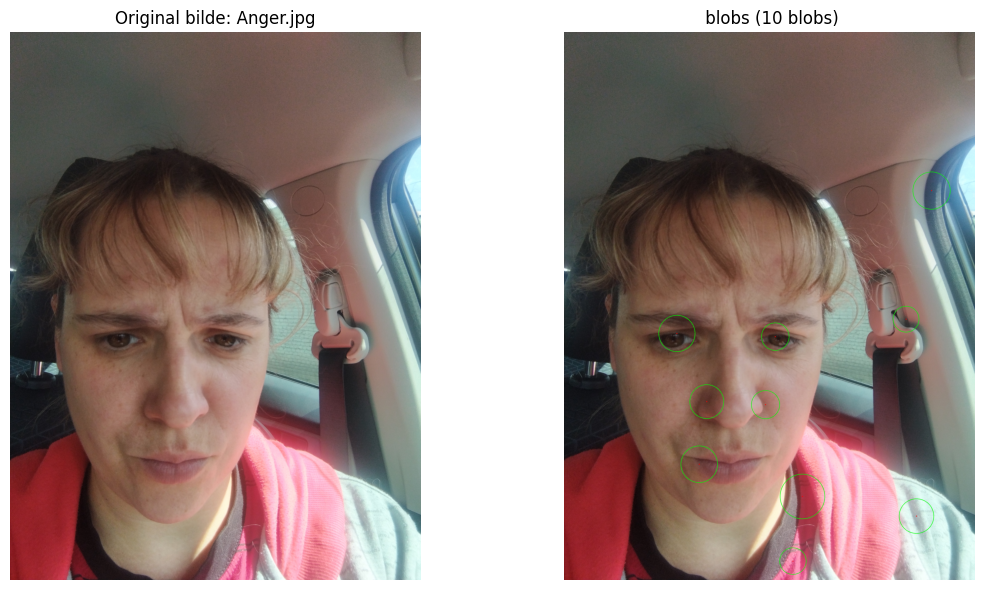


[Bilde 2/8] Prosesserer: Contempt.jpg
blobs detektert: 10
    - Blob på (1884, 1843), radius: 54px
    - Blob på (1250, 1775), radius: 85px
    - Blob på (226, 2642), radius: 82px
    - Blob på (1905, 2288), radius: 100px
    - Blob på (1671, 1850), radius: 72px
    - Blob på (1328, 2367), radius: 77px
    - Blob på (667, 3056), radius: 105px
    - Blob på (2277, 2825), radius: 81px
    - Blob på (1670, 3163), radius: 94px
    - Blob på (1962, 2132), radius: 104px


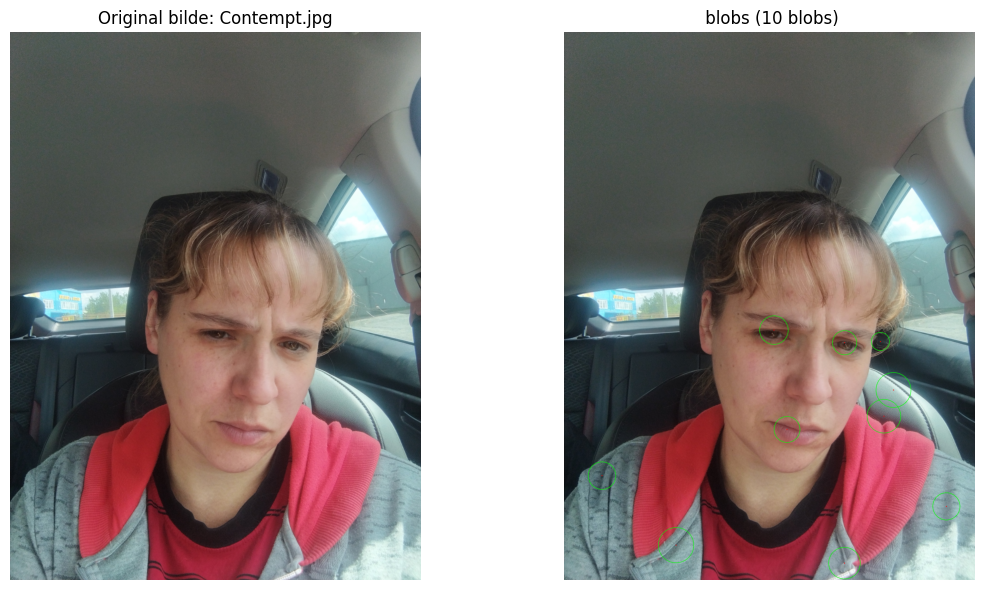


[Bilde 3/8] Prosesserer: Disgust.jpg
blobs detektert: 9
    - Blob på (761, 2930), radius: 105px
    - Blob på (1739, 2103), radius: 114px
    - Blob på (1194, 1574), radius: 88px
    - Blob på (1560, 1456), radius: 86px
    - Blob på (1724, 2845), radius: 112px
    - Blob på (300, 2871), radius: 186px
    - Blob på (504, 2972), radius: 78px
    - Blob på (1660, 1293), radius: 90px
    - Blob på (1496, 2960), radius: 137px


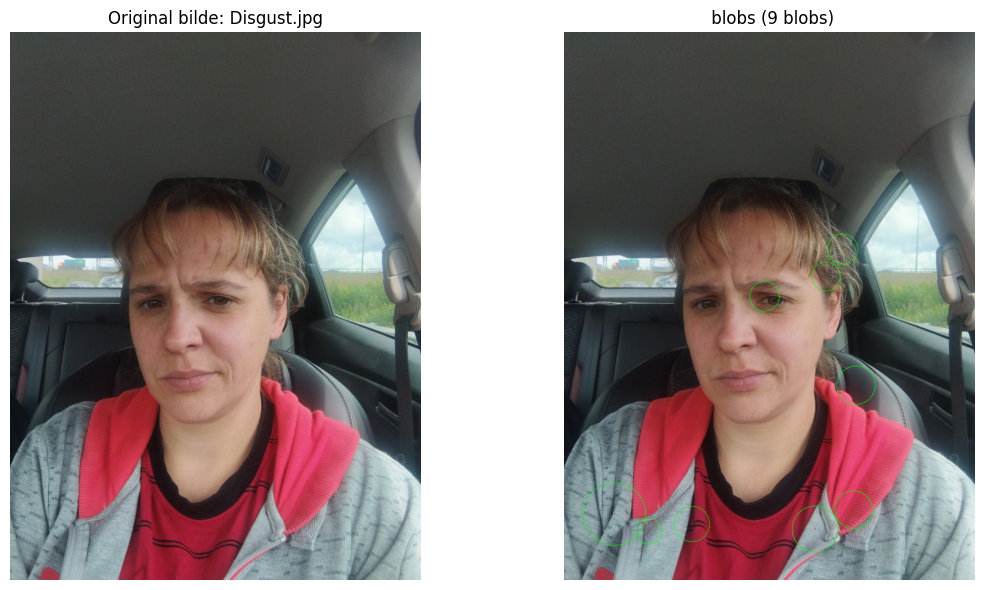


[Bilde 4/8] Prosesserer: Fear.jpg
blobs detektert: 10
    - Blob på (1441, 1633), radius: 91px
    - Blob på (890, 1623), radius: 119px
    - Blob på (1677, 2711), radius: 117px
    - Blob på (1072, 2323), radius: 90px
    - Blob på (1445, 1466), radius: 80px
    - Blob på (1572, 2687), radius: 103px
    - Blob på (1740, 1346), radius: 70px
    - Blob på (2209, 3065), radius: 58px
    - Blob på (1811, 2415), radius: 120px
    - Blob på (2010, 1801), radius: 75px


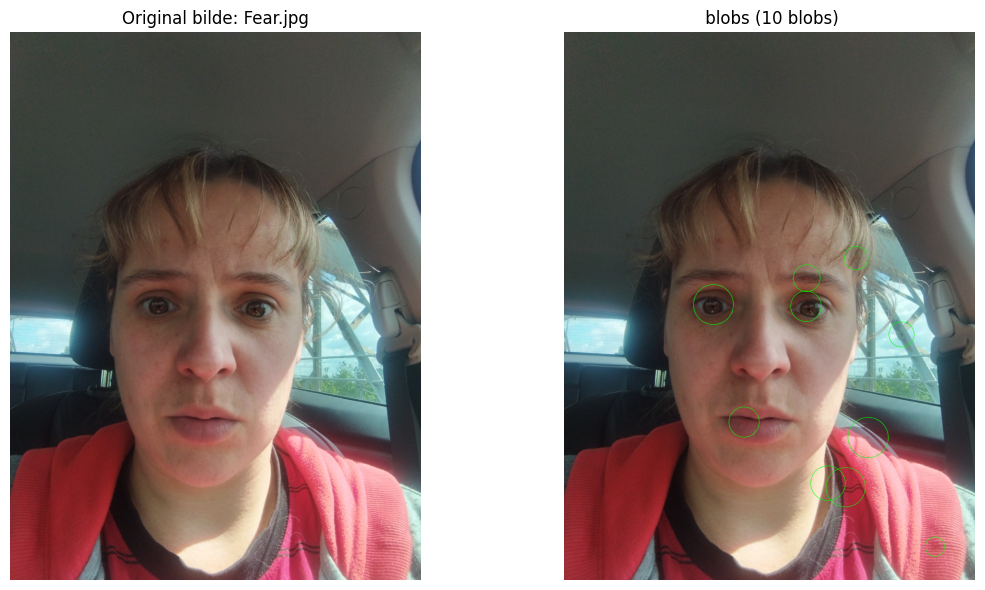


[Bilde 5/8] Prosesserer: Happy.jpg
blobs detektert: 7
    - Blob på (813, 1598), radius: 75px
    - Blob på (530, 1337), radius: 69px
    - Blob på (1337, 1637), radius: 68px
    - Blob på (1855, 2366), radius: 158px
    - Blob på (972, 2280), radius: 111px
    - Blob på (1339, 2075), radius: 95px
    - Blob på (2228, 1871), radius: 135px


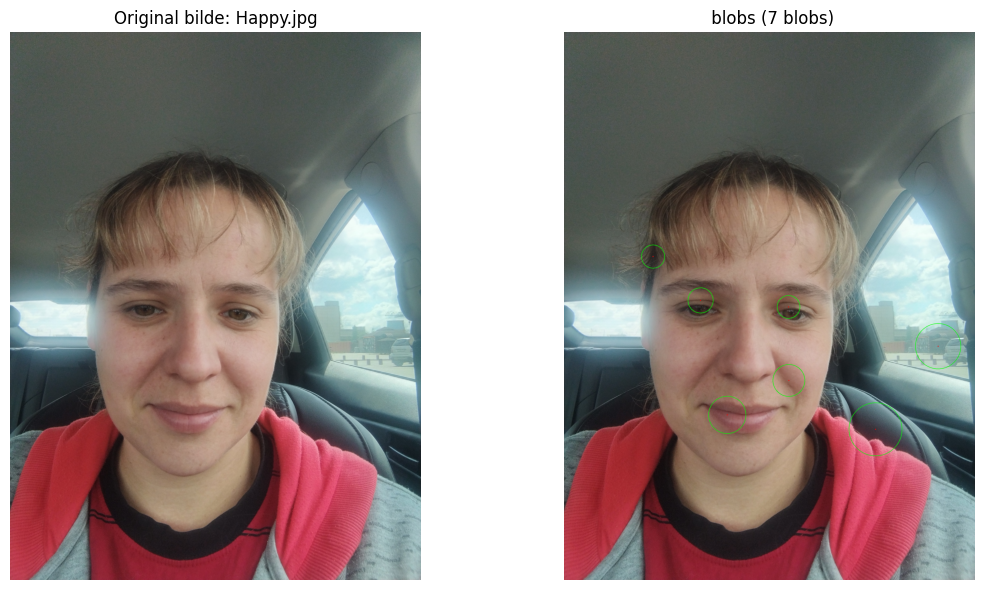


[Bilde 6/8] Prosesserer: Neutral.jpg
blobs detektert: 5
    - Blob på (303, 2869), radius: 107px
    - Blob på (1867, 2357), radius: 79px
    - Blob på (920, 1410), radius: 87px
    - Blob på (633, 1271), radius: 103px
    - Blob på (954, 1736), radius: 54px


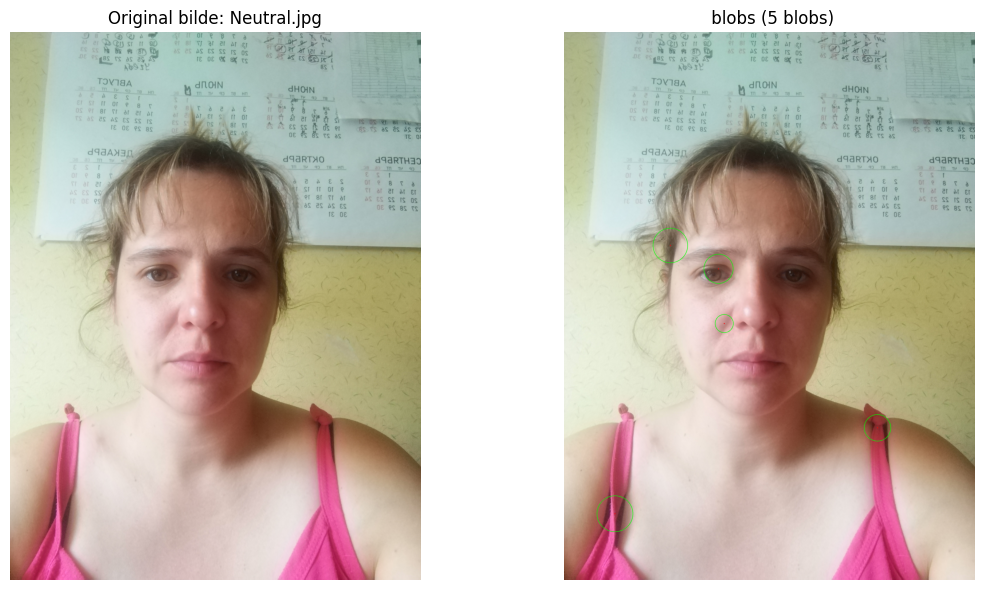


[Bilde 7/8] Prosesserer: Sad.jpg
blobs detektert: 6
    - Blob på (795, 1519), radius: 130px
    - Blob på (1258, 1510), radius: 75px
    - Blob på (974, 1897), radius: 108px
    - Blob på (1787, 758), radius: 235px
    - Blob på (1571, 1953), radius: 101px
    - Blob på (1253, 1882), radius: 88px


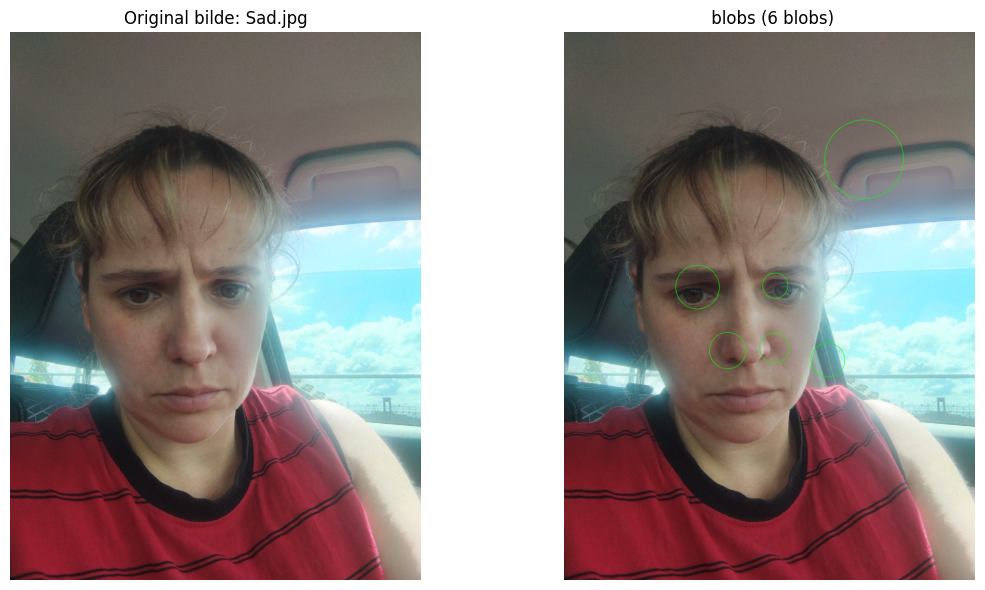


[Bilde 8/8] Prosesserer: Surprised.jpg
blobs detektert: 9
    - Blob på (1501, 734), radius: 59px
    - Blob på (976, 1544), radius: 75px
    - Blob på (949, 1309), radius: 118px
    - Blob på (1200, 2260), radius: 84px
    - Blob på (1523, 1548), radius: 86px
    - Blob på (1209, 1915), radius: 82px
    - Blob på (2133, 3062), radius: 64px
    - Blob på (1576, 1358), radius: 77px
    - Blob på (1586, 3179), radius: 72px


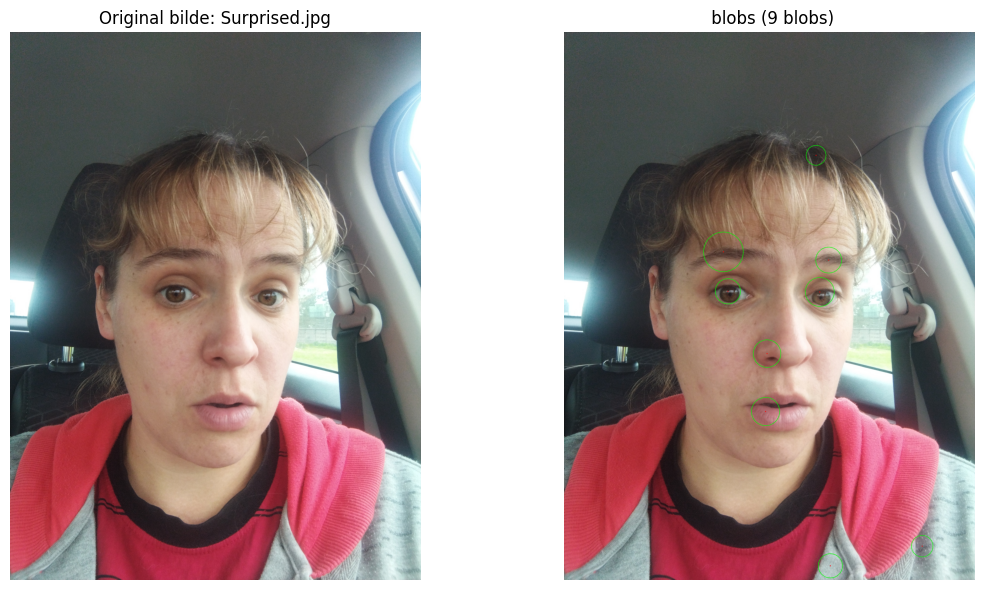


✓ Blob detection ferdig!


In [49]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Definer folderen
FOLDER = Path("bildeoppgave2/fjes/2/")
#FOLDER = Path("bildeoppgave2/carsblob/hatchback/")  


# Sett opp blob detector
params = cv2.SimpleBlobDetector_Params()

# Filter etter område
params.filterByArea = True
params.minArea = 5000
params.maxArea = 50000

# Filter etter konveksitet
params.filterByConvexity = True
params.minConvexity = 0.1

# Filter etter inertia
params.filterByInertia = True
params.minInertiaRatio = 0.01

# Lag detektoren
detector = cv2.SimpleBlobDetector_create(params)

# Hent alle bildene fra folderen
image_files = sorted(FOLDER.glob("*.jpg")) + sorted(FOLDER.glob("*.png"))

print(f"Fant {len(image_files)} bilder i {FOLDER}")
print("-" * 60)

# Prosesser hver bildefil
for idx, img_path in enumerate(image_files, 1):
    print(f"\n[Bilde {idx}/{len(image_files)}] Prosesserer: {img_path.name}")
    
    # Les bildet
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"  ⚠️ Kunne ikke lese bildet")
        continue
    
    # Konverter til gråtoner for blob detection
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Detekter blobs
    keypoints = detector.detect(gray)
    
    print(f"blobs detektert: {len(keypoints)}")
    
    # Tegn blobs på originalbildet
    img_with_blobs = img.copy()
    
    for kp in keypoints:
        # Tegn sirkel rundt hver blob
        x, y = int(kp.pt[0]), int(kp.pt[1])
        radius = int(kp.size / 2)
        cv2.circle(img_with_blobs, (x, y), radius, (0, 255, 0), 2)
        cv2.circle(img_with_blobs, (x, y), 3, (0, 0, 255), -1)  # Senter
        
        print(f"    - Blob på ({x}, {y}), radius: {radius}px")
    
    # Vis bildet med blobs
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Original bilde: {img_path.name}")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img_with_blobs, cv2.COLOR_BGR2RGB))
    plt.title(f" blobs ({len(keypoints)} blobs)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 60)
print("✓ Blob detection ferdig!")
print("=" * 60)

In [7]:
#imports
import cv2
from matplotlib import pyplot as plt
import numpy as np

#loading img
file = "Oppgave_2\\bildeoppgave2\\fjes\\2\Anger.jpg"
img = cv2.imread(file)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

#conversion
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
thresh = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 21, 5)

#Func to find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
detected_contours = img.copy()
cv2.drawContours(detected_contours, contours, -1, (0, 255, 0), -1)
plt.imshow(detected_contours)
plt.title('Detected contours')
plt.show()

contours, _ = cv2.findContours(
    thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#masking img
highlight = np.ones_like(img)
cv2.drawContours(highlight, contours, -1, (0, 200, 175), cv2.FILLED)
plt.imshow(highlight)
plt.title('Highlight contour with color')
plt.show()

#masking again
mask = np.zeros_like(img)
cv2.drawContours(mask, contours, -1, (255, 255, 255), cv2.FILLED)
foreground = cv2.bitwise_and(img, mask)

#edges
plt.imshow(foreground)
plt.title('Extract contours')
plt.show()

print("\t")

#--main-plot--
contours = {"Original": img, "Detected contours": detected_contours,
            "Color contours": highlight, "Extract contours": foreground}
plt.subplots_adjust(wspace=.2, hspace=.2)
plt.tight_layout()

for i, (key, value) in enumerate(contours.items()):
    plt.subplot(2, 2, i + 1)
    plt.tick_params(labelbottom=False)
    plt.tick_params(labelleft=False)
    plt.title("{}".format(key))
    plt.imshow(value)

plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\A'
<>:7: SyntaxWarning: invalid escape sequence '\A'
C:\Users\hanev\AppData\Local\Temp\ipykernel_12316\2020560098.py:7: SyntaxWarning: invalid escape sequence '\A'
  file = "Oppgave_2\\bildeoppgave2\\fjes\\2\Anger.jpg"
C:\Users\hanev\AppData\Local\Temp\ipykernel_12316\2020560098.py:7: SyntaxWarning: invalid escape sequence '\A'
  file = "Oppgave_2\\bildeoppgave2\\fjes\\2\Anger.jpg"


error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


Fant 8 bilder i bildeoppgave2\fjes\1
------------------------------------------------------------

[Bilde 1/8] Prosesserer: Anger.jpg
Konturer detektert (etter filtrering): 85
  - Kontur 1: areal = 72.50 px^2, perimeter = 33.07 px
  - Kontur 2: areal = 295.00 px^2, perimeter = 94.28 px
  - Kontur 3: areal = 8.00 px^2, perimeter = 12.00 px
  - Kontur 4: areal = 4.00 px^2, perimeter = 8.00 px
  - Kontur 5: areal = 150.00 px^2, perimeter = 68.63 px
  - Kontur 6: areal = 34.00 px^2, perimeter = 22.49 px
  - Kontur 7: areal = 12203.00 px^2, perimeter = 524.71 px
  - Kontur 8: areal = 202.00 px^2, perimeter = 57.46 px
  - Kontur 9: areal = 20.50 px^2, perimeter = 18.24 px
  - Kontur 10: areal = 76739.00 px^2, perimeter = 1147.23 px
  - Kontur 11: areal = 176.50 px^2, perimeter = 55.36 px
  - Kontur 12: areal = 626.00 px^2, perimeter = 122.91 px
  - Kontur 13: areal = 138.50 px^2, perimeter = 52.04 px
  - Kontur 14: areal = 722.50 px^2, perimeter = 109.15 px
  - Kontur 15: areal = 139.50 px^2

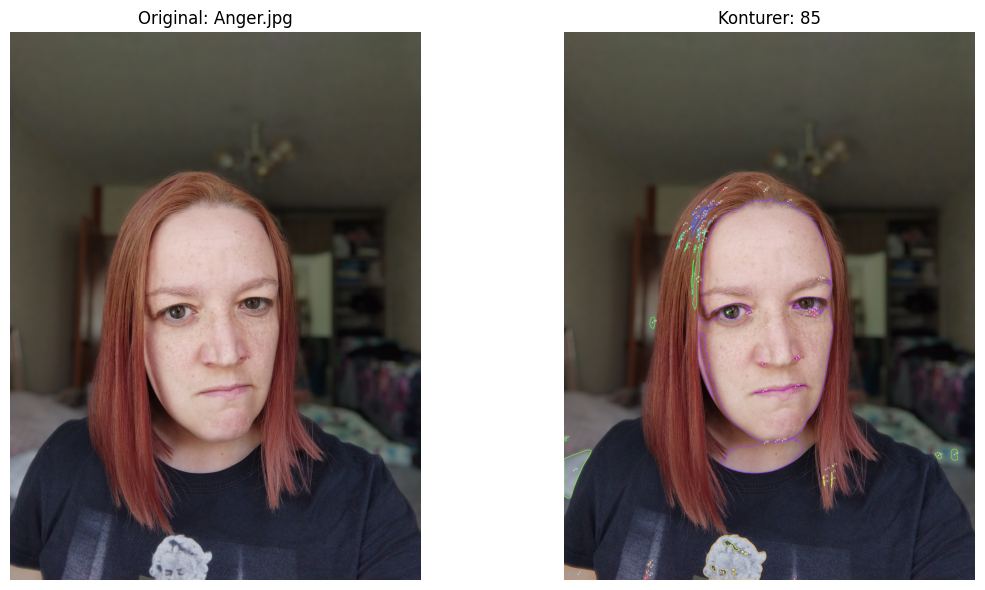


[Bilde 2/8] Prosesserer: Contempt.jpg
Konturer detektert (etter filtrering): 67
  - Kontur 1: areal = 20.00 px^2, perimeter = 17.66 px
  - Kontur 2: areal = 34.00 px^2, perimeter = 28.49 px
  - Kontur 3: areal = 28787.50 px^2, perimeter = 839.29 px
  - Kontur 4: areal = 90.50 px^2, perimeter = 37.56 px
  - Kontur 5: areal = 27.50 px^2, perimeter = 19.90 px
  - Kontur 6: areal = 1421.00 px^2, perimeter = 241.42 px
  - Kontur 7: areal = 2694.00 px^2, perimeter = 210.31 px
  - Kontur 8: areal = 566.00 px^2, perimeter = 123.25 px
  - Kontur 9: areal = 22.50 px^2, perimeter = 18.24 px
  - Kontur 10: areal = 16189.00 px^2, perimeter = 588.27 px
  - Kontur 11: areal = 36.00 px^2, perimeter = 23.31 px
  - Kontur 12: areal = 229.00 px^2, perimeter = 102.77 px
  - Kontur 13: areal = 27.00 px^2, perimeter = 22.49 px
  - Kontur 14: areal = 59.50 px^2, perimeter = 38.73 px
  - Kontur 15: areal = 2496.50 px^2, perimeter = 210.55 px
  - Kontur 16: areal = 455.50 px^2, perimeter = 90.53 px
  - Kontur

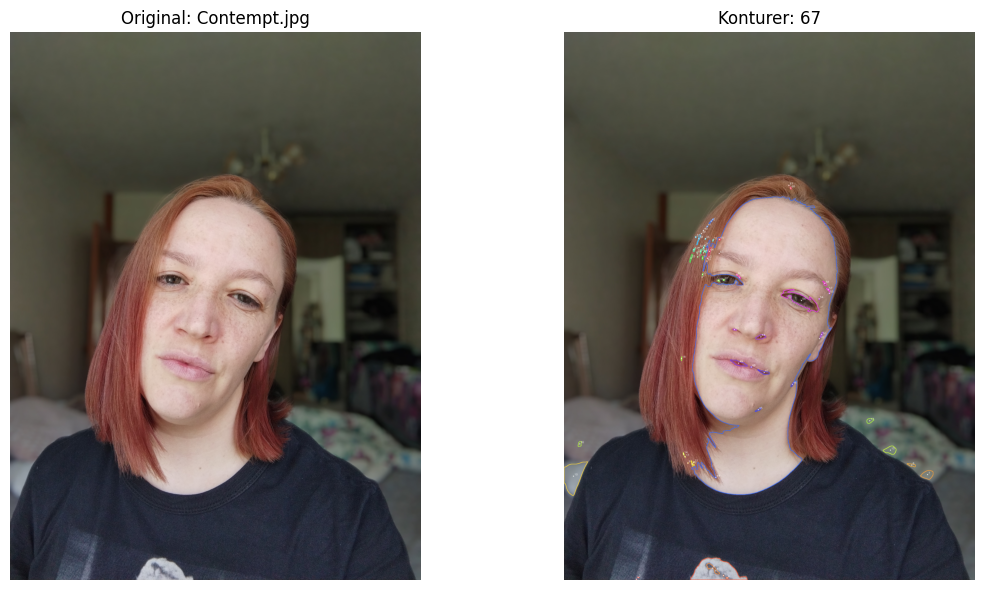


[Bilde 3/8] Prosesserer: Disgust.jpg
Konturer detektert (etter filtrering): 45
  - Kontur 1: areal = 23180.00 px^2, perimeter = 789.39 px
  - Kontur 2: areal = 1465.50 px^2, perimeter = 247.18 px
  - Kontur 3: areal = 13.00 px^2, perimeter = 14.83 px
  - Kontur 4: areal = 30859.00 px^2, perimeter = 791.21 px
  - Kontur 5: areal = 95.00 px^2, perimeter = 43.46 px
  - Kontur 6: areal = 1052.50 px^2, perimeter = 131.30 px
  - Kontur 7: areal = 27.50 px^2, perimeter = 20.24 px
  - Kontur 8: areal = 37.00 px^2, perimeter = 26.49 px
  - Kontur 9: areal = 77.50 px^2, perimeter = 44.73 px
  - Kontur 10: areal = 54.50 px^2, perimeter = 39.90 px
  - Kontur 11: areal = 1015.00 px^2, perimeter = 140.71 px
  - Kontur 12: areal = 1815.00 px^2, perimeter = 404.74 px
  - Kontur 13: areal = 15.00 px^2, perimeter = 16.83 px
  - Kontur 14: areal = 77.00 px^2, perimeter = 42.14 px
  - Kontur 15: areal = 1072.00 px^2, perimeter = 319.91 px
  - Kontur 16: areal = 21.50 px^2, perimeter = 19.07 px
  - Kontur

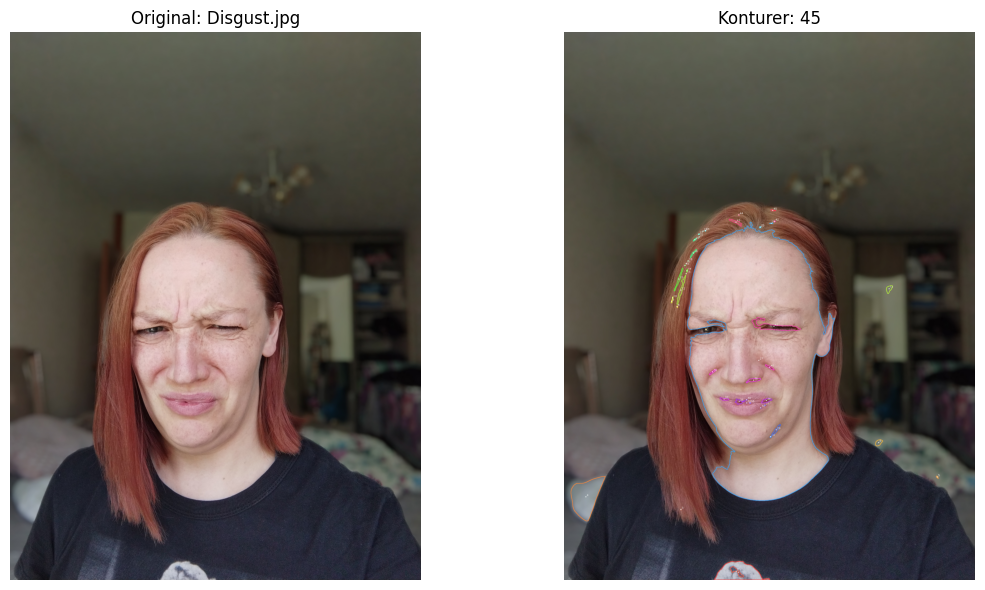


[Bilde 4/8] Prosesserer: Fear.jpg
Konturer detektert (etter filtrering): 76
  - Kontur 1: areal = 5.00 px^2, perimeter = 12.00 px
  - Kontur 2: areal = 178.50 px^2, perimeter = 62.38 px
  - Kontur 3: areal = 151.00 px^2, perimeter = 52.97 px
  - Kontur 4: areal = 54.50 px^2, perimeter = 27.90 px
  - Kontur 5: areal = 20.00 px^2, perimeter = 17.66 px
  - Kontur 6: areal = 303.50 px^2, perimeter = 91.01 px
  - Kontur 7: areal = 726.00 px^2, perimeter = 136.71 px
  - Kontur 8: areal = 203.50 px^2, perimeter = 58.38 px
  - Kontur 9: areal = 53.50 px^2, perimeter = 29.90 px
  - Kontur 10: areal = 21.00 px^2, perimeter = 17.66 px
  - Kontur 11: areal = 18.00 px^2, perimeter = 16.83 px
  - Kontur 12: areal = 13842.50 px^2, perimeter = 478.33 px
  - Kontur 13: areal = 9366.00 px^2, perimeter = 677.76 px
  - Kontur 14: areal = 99.00 px^2, perimeter = 40.63 px
  - Kontur 15: areal = 29.00 px^2, perimeter = 21.31 px
  - Kontur 16: areal = 7.00 px^2, perimeter = 9.66 px
  - Kontur 17: areal = 149

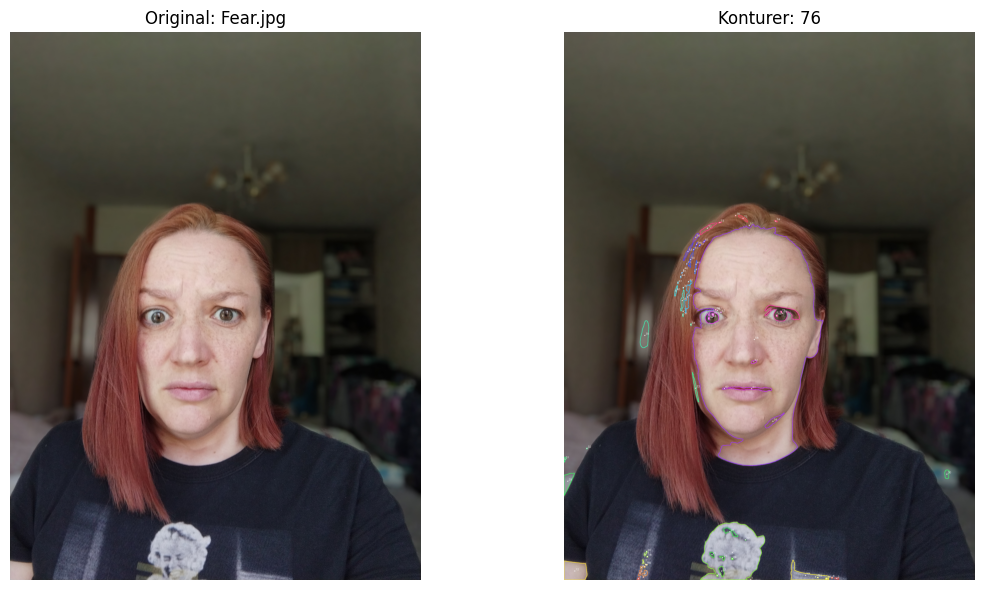


[Bilde 5/8] Prosesserer: Happy.jpg
Konturer detektert (etter filtrering): 106
  - Kontur 1: areal = 4.00 px^2, perimeter = 10.00 px
  - Kontur 2: areal = 499.00 px^2, perimeter = 280.14 px
  - Kontur 3: areal = 164.50 px^2, perimeter = 50.38 px
  - Kontur 4: areal = 32.50 px^2, perimeter = 21.90 px
  - Kontur 5: areal = 8.50 px^2, perimeter = 11.41 px
  - Kontur 6: areal = 261.00 px^2, perimeter = 76.63 px
  - Kontur 7: areal = 53.00 px^2, perimeter = 28.14 px
  - Kontur 8: areal = 67.00 px^2, perimeter = 31.31 px
  - Kontur 9: areal = 39.00 px^2, perimeter = 32.00 px
  - Kontur 10: areal = 123.00 px^2, perimeter = 46.97 px
  - Kontur 11: areal = 3761.00 px^2, perimeter = 650.98 px
  - Kontur 12: areal = 81.50 px^2, perimeter = 35.21 px
  - Kontur 13: areal = 12.50 px^2, perimeter = 14.24 px
  - Kontur 14: areal = 123.00 px^2, perimeter = 47.80 px
  - Kontur 15: areal = 23.50 px^2, perimeter = 20.24 px
  - Kontur 16: areal = 26782.00 px^2, perimeter = 1091.75 px
  - Kontur 17: areal =

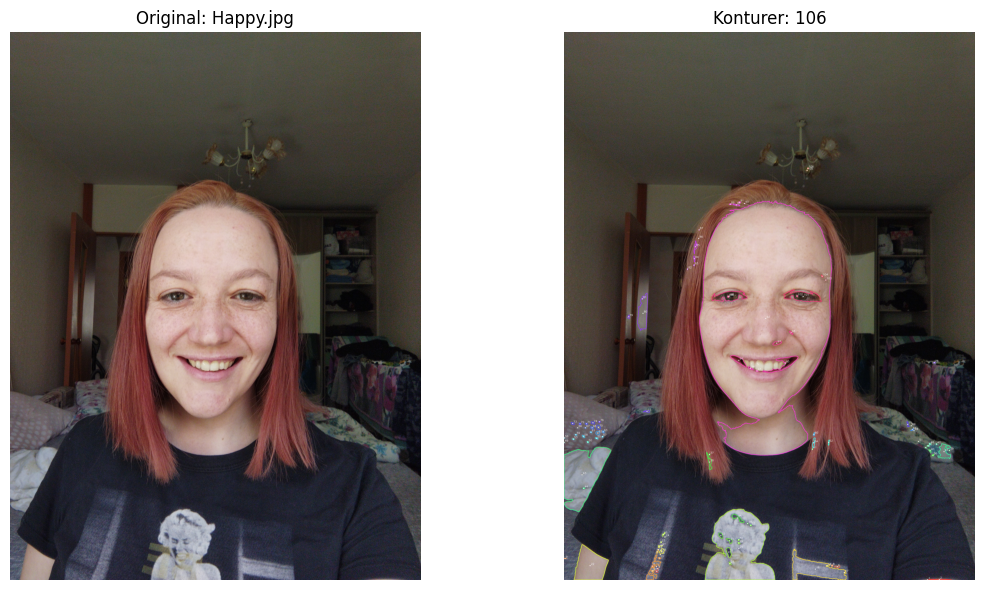


[Bilde 6/8] Prosesserer: Neutral.jpg
Konturer detektert (etter filtrering): 48
  - Kontur 1: areal = 137.00 px^2, perimeter = 65.31 px
  - Kontur 2: areal = 17.00 px^2, perimeter = 16.83 px
  - Kontur 3: areal = 30.50 px^2, perimeter = 21.90 px
  - Kontur 4: areal = 1381.00 px^2, perimeter = 184.57 px
  - Kontur 5: areal = 155.50 px^2, perimeter = 68.04 px
  - Kontur 6: areal = 1141.50 px^2, perimeter = 185.64 px
  - Kontur 7: areal = 93.00 px^2, perimeter = 39.80 px
  - Kontur 8: areal = 4.00 px^2, perimeter = 8.00 px
  - Kontur 9: areal = 348.50 px^2, perimeter = 91.84 px
  - Kontur 10: areal = 27.00 px^2, perimeter = 21.66 px
  - Kontur 11: areal = 76941.00 px^2, perimeter = 1167.32 px
  - Kontur 12: areal = 192.50 px^2, perimeter = 59.36 px
  - Kontur 13: areal = 666.00 px^2, perimeter = 153.05 px
  - Kontur 14: areal = 172.00 px^2, perimeter = 56.28 px
  - Kontur 15: areal = 688.50 px^2, perimeter = 106.33 px
  - Kontur 16: areal = 89.00 px^2, perimeter = 37.80 px
  - Kontur 17: 

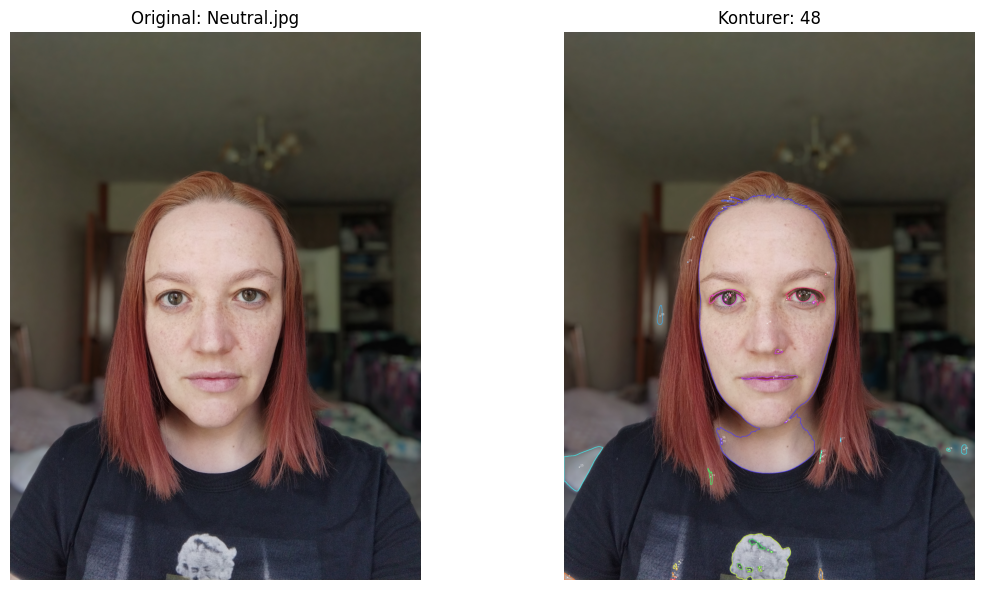


[Bilde 7/8] Prosesserer: Sad.jpg
Konturer detektert (etter filtrering): 77
  - Kontur 1: areal = 10.00 px^2, perimeter = 14.00 px
  - Kontur 2: areal = 18148.50 px^2, perimeter = 878.97 px
  - Kontur 3: areal = 12.00 px^2, perimeter = 14.83 px
  - Kontur 4: areal = 36.00 px^2, perimeter = 32.14 px
  - Kontur 5: areal = 17.00 px^2, perimeter = 18.83 px
  - Kontur 6: areal = 4.00 px^2, perimeter = 8.00 px
  - Kontur 7: areal = 4.00 px^2, perimeter = 8.00 px
  - Kontur 8: areal = 98.00 px^2, perimeter = 60.28 px
  - Kontur 9: areal = 282.00 px^2, perimeter = 150.71 px
  - Kontur 10: areal = 70.00 px^2, perimeter = 54.63 px
  - Kontur 11: areal = 47.00 px^2, perimeter = 37.31 px
  - Kontur 12: areal = 63.00 px^2, perimeter = 38.14 px
  - Kontur 13: areal = 1422.00 px^2, perimeter = 456.88 px
  - Kontur 14: areal = 410.00 px^2, perimeter = 220.57 px
  - Kontur 15: areal = 14.50 px^2, perimeter = 14.24 px
  - Kontur 16: areal = 15.50 px^2, perimeter = 17.41 px
  - Kontur 17: areal = 588.50 

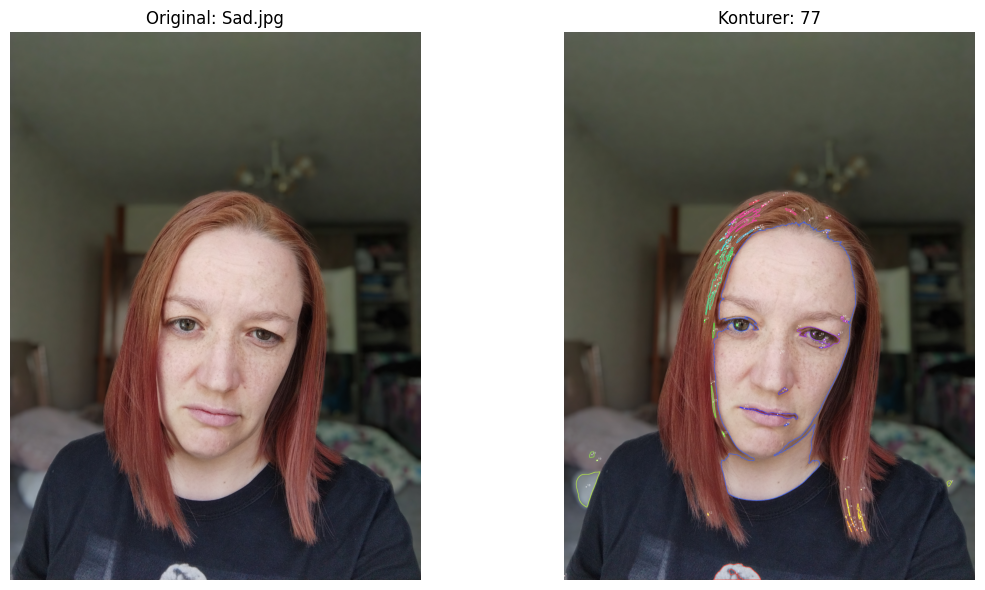


[Bilde 8/8] Prosesserer: Surprised.jpg
Konturer detektert (etter filtrering): 52
  - Kontur 1: areal = 200.50 px^2, perimeter = 80.87 px
  - Kontur 2: areal = 3062.50 px^2, perimeter = 294.47 px
  - Kontur 3: areal = 74.00 px^2, perimeter = 34.49 px
  - Kontur 4: areal = 387.00 px^2, perimeter = 98.43 px
  - Kontur 5: areal = 6.00 px^2, perimeter = 10.00 px
  - Kontur 6: areal = 4.00 px^2, perimeter = 8.00 px
  - Kontur 7: areal = 15.50 px^2, perimeter = 16.24 px
  - Kontur 8: areal = 6.00 px^2, perimeter = 10.00 px
  - Kontur 9: areal = 68992.00 px^2, perimeter = 1102.81 px
  - Kontur 10: areal = 132.00 px^2, perimeter = 47.11 px
  - Kontur 11: areal = 604.50 px^2, perimeter = 123.15 px
  - Kontur 12: areal = 111.50 px^2, perimeter = 45.21 px
  - Kontur 13: areal = 692.50 px^2, perimeter = 107.15 px
  - Kontur 14: areal = 67.50 px^2, perimeter = 33.56 px
  - Kontur 15: areal = 30.50 px^2, perimeter = 20.73 px
  - Kontur 16: areal = 1710.00 px^2, perimeter = 265.42 px
  - Kontur 17: a

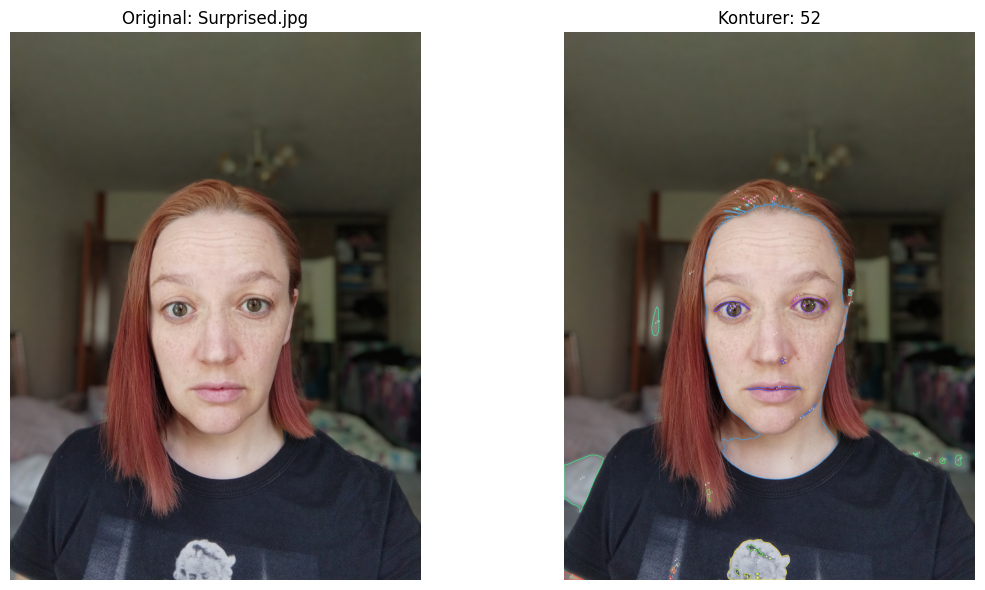


✓ Konturdeteksjon ferdig!


In [46]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# === Konfigurasjon ===
FOLDER = Path("bildeoppgave2/fjes/1")  # <— som du ønsket
MIN_AREA = 1     # filtrer vekk små konturer
MAX_AREA = 500000000000    # filtrer vekk veldig store konturer (juster ved behov)
BLUR_KSIZE = 17    # Gaussisk blur kernel (må være oddetall)
USE_RETR_MODE = cv2.RETR_TREE  # eller cv2.RETR_TREE for alle hierarkier

# --- Hjelpefunksjon: få ulike, distinkte farger for konturer ---
def color_from_index(i, n):
    """
    Generer en distinkt BGR-farge basert på indeks i [0, n).
    Vi sampler jevnt i HSV-fargerommet og konverterer til BGR.
    """
    if n <= 0:
        return (0, 255, 0)
    h = int(180 * (i / max(1, n)))  # OpenCV HSV H∈[0,180)
    hsv = np.uint8([[[h, 200, 255]]])
    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)[0, 0].tolist()
    return tuple(int(v) for v in bgr)

# Hent alle bildene fra folderen
image_files = sorted(FOLDER.glob("*.jpg")) + sorted(FOLDER.glob("*.png"))

print(f"Fant {len(image_files)} bilder i {FOLDER}")
print("-" * 60)

for idx, img_path in enumerate(image_files, 1):
    print(f"\n[Bilde {idx}/{len(image_files)}] Prosesserer: {img_path.name}")

    img = cv2.imread(str(img_path))
    if img is None:
        print("  ⚠️  Kunne ikke lese bildet.")
        continue

    # --- Forbehandling ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if BLUR_KSIZE and BLUR_KSIZE % 2 == 1:
        gray_blur = cv2.GaussianBlur(gray, (BLUR_KSIZE, BLUR_KSIZE), 0)
    else:
        gray_blur = gray

    # Otsu-threshold. Bruk THRESH_BINARY_INV hvis objektet er mørkere enn bakgrunn.
    # Prøv å bytte til THRESH_BINARY om konturene ser "invertert" ut.
    _, binary = cv2.threshold(gray_blur, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    # (Valgfritt) liten morfologisk åpning for å fjerne små flekker
    kernel = np.ones((3, 3), np.uint8)
    binary_clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

    # --- Finn konturer ---
    # OpenCV 4.x: findContours -> contours, hierarchy
    # OpenCV 3.x: findContours -> image, contours, hierarchy
    found = cv2.findContours(binary_clean, USE_RETR_MODE, cv2.CHAIN_APPROX_SIMPLE)
    if len(found) == 3:
        _, contours, hierarchy = found
    else:
        contours, hierarchy = found

    # Filtrer konturer på areal
    filtered = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if (MIN_AREA is not None and area < MIN_AREA):
            continue
        if (MAX_AREA is not None and area > MAX_AREA):
            continue
        filtered.append(cnt)

    print(f"Konturer detektert (etter filtrering): {len(filtered)}")

    # --- Statistikk per kontur ---
    total_area = 0.0
    total_perimeter = 0.0
    for i, cnt in enumerate(filtered, start=1):
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)
        total_area += area
        total_perimeter += perimeter
        print(f"  - Kontur {i}: areal = {area:.2f} px^2, perimeter = {perimeter:.2f} px")

    if len(filtered) > 0:
        print(f"  Sum areal: {total_area:.2f} px^2 | Gj.snitt areal: {total_area/len(filtered):.2f} px^2")
        print(f"  Sum perimeter: {total_perimeter:.2f} px | Gj.snitt perimeter: {total_perimeter/len(filtered):.2f} px")

    # --- Visualisering ---
    overlay = img.copy()
    n = len(filtered)
    for i, cnt in enumerate(filtered):
        color = color_from_index(i, n)  # unik farge per kontur
        cv2.drawContours(overlay, [cnt], contourIdx=-1, color=color, thickness=2)

        # (Valgfritt) tegn senter/label
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            cv2.circle(overlay, (cx, cy), 3, (255, 255, 255), -1)
            cv2.putText(overlay, f"{i+1}", (cx+5, cy-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1, cv2.LINE_AA)

    # Vis side-ved-side
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Original: {img_path.name}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"Konturer: {len(filtered)}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

print("\n" + "=" * 60)
print("✓ Konturdeteksjon ferdig!")
print("=" * 60)


In [ ]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# =================== Konfigurasjon ===================
FOLDER = Path("bildeoppgave2/fjes/4/")   # mappen du ba om
# Filtrering på areal (juster ved behov)
MIN_AREA = 200
MAX_AREA = 250_000

# Hent indre konturer (øyne/munn) og hierarki
RETR_MODE = cv2.RETR_TREE     # evt. cv2.RETR_EXTERNAL om du kun vil ha ytterkanter
APPROX_MODE = cv2.CHAIN_APPROX_SIMPLE   # evt. cv2.CHAIN_APPROX_NONE for tettere kanter

# Slå på for å se binærmasken (debug)
VIS_BINMASK = False
# =====================================================


def color_from_index(i, n):
    """Gi distinkt BGR-farge per kontur via HSV."""
    if n <= 0:
        return (0, 255, 0)
    h = int(180 * (i / max(1, n)))  # H i [0,180) i OpenCV
    hsv = np.uint8([[[h, 200, 255]]])
    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)[0, 0].tolist()
    return tuple(int(v) for v in bgr)


def make_binary_mask(img):
    """
    Lag en binærmaske uten gråskala:
    - R-kanal: THRESH_BINARY_INV + Otsu (mørke lepper/bryn blir hvite)
    - S-kanal (HSV): THRESH_BINARY + Otsu (mettet farge blir hvit)
    - Kombineres med AND for å være selektiv (reduserer hår/støy)
    """
    b, g, r = cv2.split(img)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    # Terskling
    _, r_bin = cv2.threshold(r, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
    _, s_bin = cv2.threshold(s, 0, 255, cv2.THRESH_BINARY      | cv2.THRESH_OTSU)

    binary = cv2.bitwise_and(r_bin, s_bin)

    # --- Valgfri kantforsterkning (kan hjelpe leppelukke) ---
    # edges = cv2.Canny(r, 80, 160) | cv2.Canny(s, 80, 160)
    # binary = cv2.bitwise_or(binary, edges)

    return binary


def contour_ok(cnt):
    """Form-/størrelsesfilter for å fjerne støy men beholde munn/bryn."""
    area = cv2.contourArea(cnt)
    if area < MIN_AREA or area > MAX_AREA:
        return False

    per = cv2.arcLength(cnt, True)
    if per <= 0:
        return False

    # Litt grov formvurdering for å plukke vekk flimmer
    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull) + 1e-6
    solidity = area / hull_area  # 0..1
    if solidity < 0.45:  # for "flisete" hårbiter
        return False

    return True


def process_folder(folder: Path):
    image_files = sorted(folder.glob("*.jpg")) + sorted(folder.glob("*.png"))
    print(f"Fant {len(image_files)} bilder i {folder}")
    print("-" * 60)

    for idx, img_path in enumerate(image_files, 1):
        print(f"\n[Bilde {idx}/{len(image_files)}] Prosesserer: {img_path.name}")

        img = cv2.imread(str(img_path))
        if img is None:
            print("  ⚠️  Kunne ikke lese bildet.")
            continue

        # --- Lag binærmaske uten gråskala ---
        binary = make_binary_mask(img)

        # (Valgfritt) se masken
        if VIS_BINMASK:
            plt.figure(figsize=(6, 6))
            plt.imshow(binary, cmap="gray")
            plt.title("Binærmaske")
            plt.axis("off")
            plt.show()

        # --- Finn konturer ---
        found = cv2.findContours(binary, RETR_MODE, APPROX_MODE)
        # OpenCV 3 vs 4 returformat
        if len(found) == 3:
            _, contours, hierarchy = found
        else:
            contours, hierarchy = found

        # --- Filtrer konturer ---
        filtered = [c for c in contours if contour_ok(c)]
        print(f"Konturer detektert (etter filtrering): {len(filtered)}")

        # --- Statistikk ---
        total_area = 0.0
        total_perimeter = 0.0
        for i, cnt in enumerate(filtered, start=1):
            area = cv2.contourArea(cnt)
            perim = cv2.arcLength(cnt, True)
            total_area += area
            total_perimeter += perim
            print(f"  - Kontur {i}: areal = {area:.2f} px^2, perimeter = {perim:.2f} px")

        if filtered:
            print(f"  Sum areal: {total_area:.2f} px^2 | "
                  f"Gj.snitt areal: {total_area/len(filtered):.2f} px^2")
            print(f"  Sum perimeter: {total_perimeter:.2f} px | "
                  f"Gj.snitt perimeter: {total_perimeter/len(filtered):.2f} px")

        # --- Visualisering ---
        overlay = img.copy()
        n = len(filtered)
        for i, cnt in enumerate(filtered):
            color = color_from_index(i, n)
            cv2.drawContours(overlay, [cnt], -1, color, 2)

            # Merk senter + label
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                cv2.circle(overlay, (cx, cy), 3, (255, 255, 255), -1)
                cv2.putText(overlay, f"{i+1}", (cx+5, cy-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1, cv2.LINE_AA)

        # Side-ved-side
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Original: {img_path.name}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        plt.title(f"Konturer: {len(filtered)}")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

    print("\n" + "=" * 60)
    print("✓ Konturdeteksjon ferdig!")
    print("=" * 60)


if __name__ == "__main__":
    process_folder(FOLDER)
